In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# set path

project_dir = r"C:\Users\kjdac\OneDrive\Desktop\PORTFOLIO PROJECTS\Health_Insurance_claims_member_engagement"

processed_dir = os.path.join(project_dir, "data_processed")
outputs_dir = os.path.join(project_dir, "outputs")
tables_dir = os.path.join(outputs_dir, "tables")
charts_dir = os.path.join(outputs_dir, "charts")

os.makedirs(processed_dir, exist_ok=True)
os.makedirs(outputs_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(charts_dir, exist_ok=True)

print("Processed dir:", processed_dir)

Processed dir: C:\Users\kjdac\OneDrive\Desktop\PORTFOLIO PROJECTS\Health_Insurance_claims_member_engagement\data_processed


In [3]:
# load member-level dataset

member_features = pd.read_csv(
    os.path.join(processed_dir, "member_features_2010.csv"),
    low_memory=False
)

print("member_features shape:", member_features.shape)
member_features.head()

member_features shape: (112754, 58)


,DESYNPUF_ID,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,...,outpatient_total_deductible,outpatient_total_coinsurance,outpatient_total_blood_deductible,outpatient_avg_diag_count,has_outpatient_claim,age_2010,chronic_condition_count,total_paid_all_claims,high_cost_member,log_total_paid_all_claims
0,00013D2EFD8E45D1,1970-01-01 00:00:00.019230501,NaN,1,1,0,26,950,12,12,...,0.0,10.0,0.0,2.0,1.0,40.99384,2,4050.0,0,8.306719
1,00016F745862898F,1970-01-01 00:00:00.019430101,NaN,1,1,Y,39,230,12,12,...,0.0,70.0,0.0,4.5,1.0,40.99384,4,52060.0,1,10.860171
2,0001FDD721E223DC,1970-01-01 00:00:00.019360901,NaN,2,1,0,39,280,12,12,...,0.0,50.0,0.0,4.0,1.0,40.99384,0,30.0,0,3.433987
3,00021CA6FF03E670,1970-01-01 00:00:00.019410601,NaN,1,5,0,6,290,12,12,...,0.0,0.0,0.0,0.0,0.0,40.99384,0,0.0,0,0.000000
4,00024B3D2352D2D0,1970-01-01 00:00:00.019360801,NaN,1,1,0,52,590,9,12,...,0.0,80.0,0.0,1.5,1.0,40.99384,0,160.0,0,5.081404


In [4]:
# re-convert date files if needed

date_cols = ["BENE_BIRTH_DT", "BENE_DEATH_DT"]

for col in date_cols:
    member_features[col] = pd.to_datetime(member_features[col], errors="coerce")

member_features[date_cols].dtypes

BENE_BIRTH_DT    datetime64[ns]
BENE_DEATH_DT    datetime64[ns]
dtype: object

In [5]:
# variables we’ll use to drive engagement simulation

member_features[[
    "DESYNPUF_ID",
    "age_2010",
    "chronic_condition_count",
    "inpatient_claim_count",
    "outpatient_claim_count",
    "total_paid_all_claims",
    "high_cost_member"
]].head()

,DESYNPUF_ID,age_2010,chronic_condition_count,inpatient_claim_count,outpatient_claim_count,total_paid_all_claims,high_cost_member
0,00013D2EFD8E45D1,40.99384,2,1.0,1.0,4050.0,0
1,00016F745862898F,40.99384,4,4.0,2.0,52060.0,1
2,0001FDD721E223DC,40.99384,0,0.0,1.0,30.0,0
3,00021CA6FF03E670,40.99384,0,0.0,0.0,0.0,0
4,00024B3D2352D2D0,40.99384,0,0.0,4.0,160.0,0


In [6]:
# create random seed

np.random.seed(42)

In [7]:
# create features for simulation (we want engagement to vary somewhat by member characteristics)

member_features["cost_percentile"] = member_features["total_paid_all_claims"].rank(pct=True)
member_features["outpatient_percentile"] = member_features["outpatient_claim_count"].rank(pct=True)
member_features["chronic_percentile"] = member_features["chronic_condition_count"].rank(pct=True)
member_features["age_percentile"] = member_features["age_2010"].rank(pct=True)

In [8]:
# simulate portal logins

portal_lambda = (
    2
    + 6 * member_features["outpatient_percentile"]
    + 3 * member_features["chronic_percentile"]
    - 2 * member_features["age_percentile"]
)

portal_lambda = np.clip(portal_lambda, 0.5, None)

member_features["portal_logins_90d"] = np.random.poisson(portal_lambda).astype(int)

In [9]:
# simulate app sessions

app_lambda = 1 + member_features["portal_logins_90d"] * 0.8
member_features["app_sessions_90d"] = np.random.poisson(app_lambda).astype(int)

In [10]:
# simulate care reminder clicks

reminder_lambda = (
    0.5
    + 1.5 * member_features["chronic_percentile"]
    + 0.2 * member_features["portal_logins_90d"]
)

reminder_lambda = np.clip(reminder_lambda, 0.1, None)

member_features["care_reminder_clicks_90d"] = np.random.poisson(reminder_lambda).astype(int)

In [11]:
# simulate messages sent to care team

message_lambda = (
    0.3
    + 1.0 * member_features["chronic_percentile"]
    + 0.00005 * member_features["total_paid_all_claims"]
)

message_lambda = np.clip(message_lambda, 0.1, 8)

member_features["care_team_messages_90d"] = np.random.poisson(message_lambda).astype(int)

In [12]:
# simulate telehealth scheduling

telehealth_prob = (
    0.05
    + 0.20 * member_features["outpatient_percentile"]
    + 0.15 * member_features["chronic_percentile"]
)

telehealth_prob = np.clip(telehealth_prob, 0.01, 0.85)

member_features["scheduled_telehealth_90d"] = np.random.binomial(1, telehealth_prob)

In [13]:
# simulate preventive care content views

preventive_lambda = (
    1
    + 1.5 * member_features["portal_logins_90d"] / 5
    + 0.8 * member_features["chronic_percentile"]
)

preventive_lambda = np.clip(preventive_lambda, 0.1, None)

member_features["preventive_content_views_90d"] = np.random.poisson(preventive_lambda).astype(int)

In [14]:
# create composite engagement sscore

member_features["engagement_score"] = (
    member_features["portal_logins_90d"] * 1.0
    + member_features["app_sessions_90d"] * 0.75
    + member_features["care_reminder_clicks_90d"] * 1.5
    + member_features["care_team_messages_90d"] * 2.0
    + member_features["scheduled_telehealth_90d"] * 3.0
    + member_features["preventive_content_views_90d"] * 1.25
)

In [15]:
# create engagement tiers

member_features["engagement_tier"] = pd.qcut(
    member_features["engagement_score"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

In [16]:
# create a low engagement flag

member_features["low_engagement_member"] = (
    member_features["engagement_tier"] == "Low"
).astype(int)

In [17]:
# create a simple outreach priority flag

member_features["outreach_priority_flag"] = (
    (
        (member_features["high_cost_member"] == 1) &
        (member_features["low_engagement_member"] == 1)
    ) |
    (
        (member_features["chronic_condition_count"] >= 3) &
        (member_features["low_engagement_member"] == 1)
    ) |
    (
        (member_features["inpatient_claim_count"] > 0) &
        (member_features["low_engagement_member"] == 1)
    )
).astype(int)

In [18]:
# quick sanity check of engagement variables

member_features[[
    "portal_logins_90d",
    "app_sessions_90d",
    "care_reminder_clicks_90d",
    "care_team_messages_90d",
    "scheduled_telehealth_90d",
    "preventive_content_views_90d",
    "engagement_score"
]].describe()

,portal_logins_90d,app_sessions_90d,care_reminder_clicks_90d,care_team_messages_90d,scheduled_telehealth_90d,preventive_content_views_90d,engagement_score
count,112754.000000,112754.000000,112754.000000,112754.000000,112754.000000,112754.000000,112754.000000
mean,5.509596,5.408544,2.352005,1.175027,0.225748,3.055173,19.940277
std,3.309613,3.523320,1.812749,1.413181,0.418076,2.090232,10.320882
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,3.000000,1.000000,0.000000,0.000000,2.000000,12.000000
50%,5.000000,5.000000,2.000000,1.000000,0.000000,3.000000,18.750000
75%,8.000000,7.000000,3.000000,2.000000,0.000000,4.000000,26.500000
max,23.000000,27.000000,14.000000,17.000000,1.000000,17.000000,77.750000


In [19]:
# engagement tier counts

print(member_features["engagement_tier"].value_counts(dropna=False))

engagement_tier
Low          29069
Medium       28160
Very High    28097
High         27428
Name: count, dtype: int64


In [20]:
# outreach priority counts

print(member_features["outreach_priority_flag"].value_counts(dropna=False))
print(member_features["outreach_priority_flag"].value_counts(normalize=True).round(4))

outreach_priority_flag
0    109779
1      2975
Name: count, dtype: int64
outreach_priority_flag
0    0.9736
1    0.0264
Name: proportion, dtype: float64


In [21]:
# summary by engagement tier

engagement_summary = (
    member_features.groupby("engagement_tier")[[
        "age_2010",
        "chronic_condition_count",
        "inpatient_claim_count",
        "outpatient_claim_count",
        "total_paid_all_claims",
        "high_cost_member",
        "outreach_priority_flag"
    ]]
    .mean()
    .round(2)
    .reset_index()
)

engagement_summary

C:\Users\kjdac\AppData\Local\Temp\ipykernel_5244\3818862929.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  member_features.groupby("engagement_tier")[[


,engagement_tier,age_2010,chronic_condition_count,inpatient_claim_count,outpatient_claim_count,total_paid_all_claims,high_cost_member,outreach_priority_flag
0,Low,40.99,0.32,0.11,1.29,1134.90,0.04,0.1
1,Medium,40.99,1.19,0.33,4.37,3854.87,0.15,0.0
2,High,40.99,2.30,0.68,8.45,8275.58,0.30,0.0
3,Very High,40.99,3.46,1.24,13.86,17242.72,0.51,0.0


In [22]:
# save engagement summary table

engagement_summary.to_csv(
    os.path.join(tables_dir, "engagement_tier_summary.csv"),
    index=False
)

print("Saved engagement tier summary.")

Saved engagement tier summary.


In [23]:
# high-cost rate by engagement tier

high_cost_by_engagement = (
    member_features.groupby("engagement_tier")["high_cost_member"]
    .mean()
    .round(4)
    .reset_index()
)

high_cost_by_engagement["high_cost_pct"] = high_cost_by_engagement["high_cost_member"] * 100
high_cost_by_engagement

C:\Users\kjdac\AppData\Local\Temp\ipykernel_5244\1778352403.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  member_features.groupby("engagement_tier")["high_cost_member"]


,engagement_tier,high_cost_member,high_cost_pct
0,Low,0.0438,4.38
1,Medium,0.1478,14.78
2,High,0.3043,30.43
3,Very High,0.5133,51.33


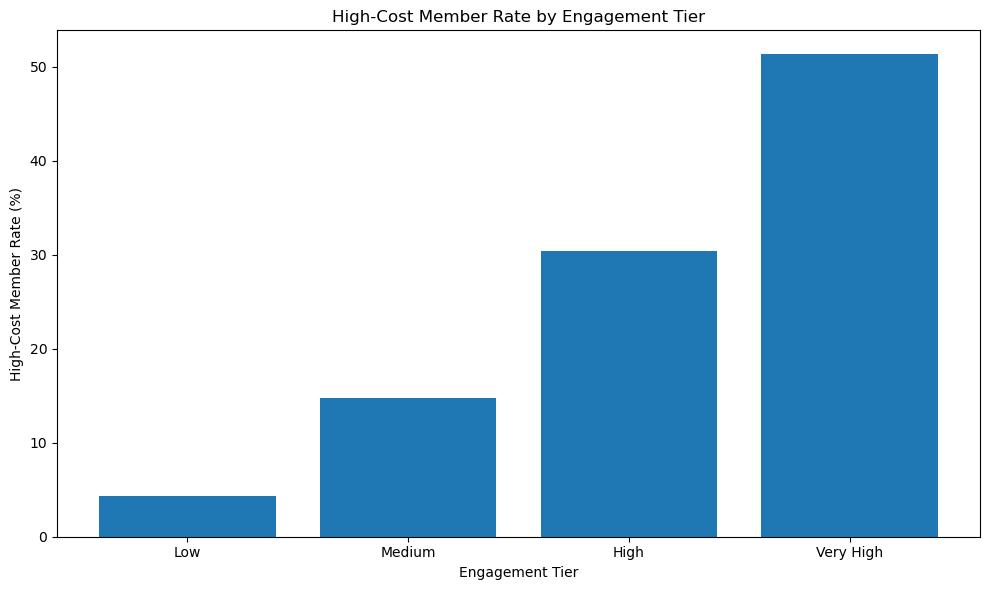

In [24]:
# plot high-cost rate by engagement tier

plt.figure(figsize=(10, 6))
plt.bar(
    high_cost_by_engagement["engagement_tier"].astype(str),
    high_cost_by_engagement["high_cost_pct"]
)
plt.title("High-Cost Member Rate by Engagement Tier")
plt.xlabel("Engagement Tier")
plt.ylabel("High-Cost Member Rate (%)")
plt.tight_layout()
plt.show()

In [25]:
# outreach priority rate by engagement tier

outreach_by_engagement = (
    member_features.groupby("engagement_tier")["outreach_priority_flag"]
    .mean()
    .round(4)
    .reset_index()
)

outreach_by_engagement["outreach_priority_pct"] = outreach_by_engagement["outreach_priority_flag"] * 100
outreach_by_engagement

C:\Users\kjdac\AppData\Local\Temp\ipykernel_5244\2130344555.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  member_features.groupby("engagement_tier")["outreach_priority_flag"]


,engagement_tier,outreach_priority_flag,outreach_priority_pct
0,Low,0.1023,10.23
1,Medium,0.0000,0.00
2,High,0.0000,0.00
3,Very High,0.0000,0.00


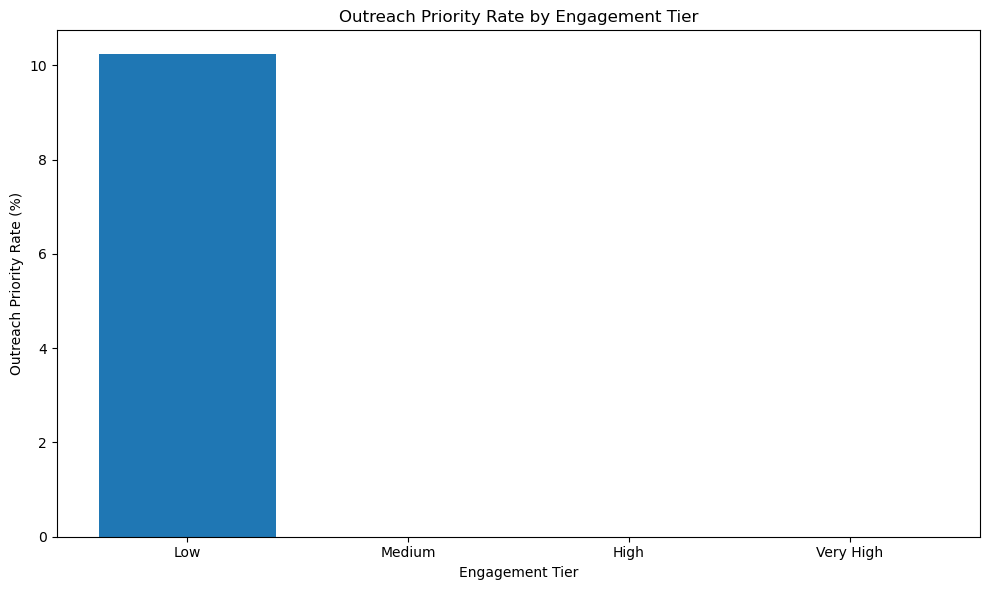

In [28]:
# plot outreach priority rate by engagement tier

plt.figure(figsize=(10, 6))
plt.bar(
    outreach_by_engagement["engagement_tier"].astype(str),
    outreach_by_engagement["outreach_priority_pct"]
)
plt.title("Outreach Priority Rate by Engagement Tier")
plt.xlabel("Engagement Tier")
plt.ylabel("Outreach Priority Rate (%)")
plt.tight_layout()
plt.show()

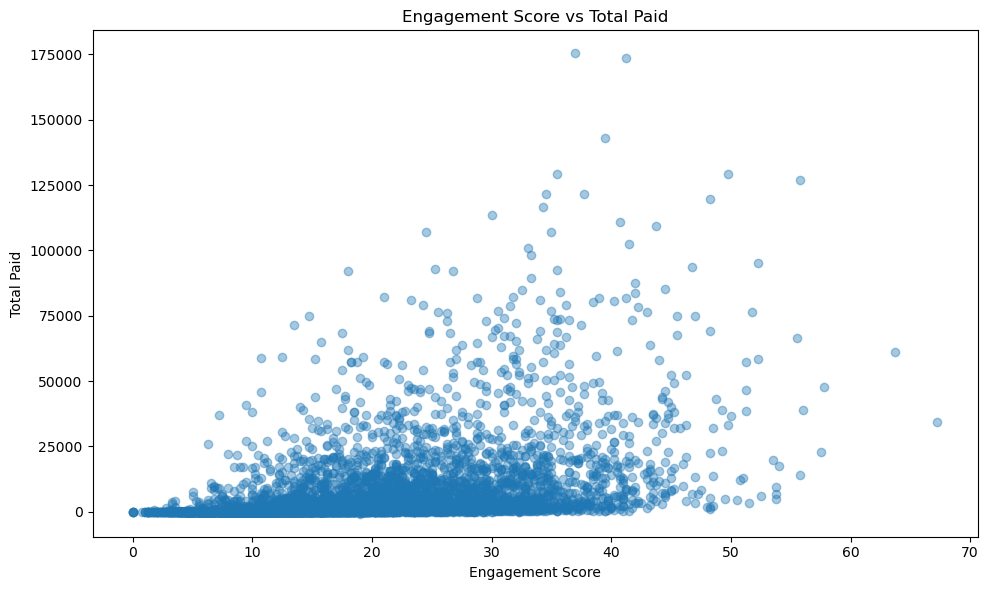

In [29]:
# engagement vs. total paid scatter sample

plot_sample = member_features.sample(
    n=min(5000, len(member_features)),
    random_state=42
)

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_sample["engagement_score"],
    plot_sample["total_paid_all_claims"],
    alpha=0.4
)
plt.title("Engagement Score vs Total Paid")
plt.xlabel("Engagement Score")
plt.ylabel("Total Paid")
plt.tight_layout()
plt.show()

In [30]:
# save clean engagement table separately

engagement_table = member_features[[
    "DESYNPUF_ID",
    "portal_logins_90d",
    "app_sessions_90d",
    "care_reminder_clicks_90d",
    "care_team_messages_90d",
    "scheduled_telehealth_90d",
    "preventive_content_views_90d",
    "engagement_score",
    "engagement_tier",
    "low_engagement_member",
    "outreach_priority_flag"
]].copy()

engagement_table.to_csv(
    os.path.join(processed_dir, "member_engagement_simulated.csv"),
    index=False
)

print("Saved member engagement table.")

Saved member engagement table.


In [31]:
# save fully merged dataset 

member_features.to_csv(
    os.path.join(processed_dir, "member_features_with_engagement_2010.csv"),
    index=False
)

print("Saved merged member-level dataset with engagement.")

Saved merged member-level dataset with engagement.


In [32]:
# save summary workbook

with pd.ExcelWriter(os.path.join(tables_dir, "engagement_summary_tables.xlsx")) as writer:
    engagement_summary.to_excel(writer, sheet_name="engagement_summary", index=False)
    high_cost_by_engagement.to_excel(writer, sheet_name="high_cost_by_engagement", index=False)
    outreach_by_engagement.to_excel(writer, sheet_name="outreach_by_engagement", index=False)

print("Saved engagement summary workbook.")

Saved engagement summary workbook.


In [33]:
# key findings

print("""
Initial engagement findings:
1. Member engagement metrics were simulated to reflect plausible variation by utilization, age, and chronic burden.
2. Engagement tiers can be used to profile members by cost and outreach need.
3. Members with low engagement and higher claim burden can be flagged for outreach prioritization.
4. The merged dataset now supports both predictive modeling and business-facing segmentation analysis.
""")


Initial engagement findings:
1. Member engagement metrics were simulated to reflect plausible variation by utilization, age, and chronic burden.
2. Engagement tiers can be used to profile members by cost and outreach need.
3. Members with low engagement and higher claim burden can be flagged for outreach prioritization.
4. The merged dataset now supports both predictive modeling and business-facing segmentation analysis.

